In [ ]:
!pip install opencv-python scikit-image scikit-learn matplotlib kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import os

print("Downloaded path:", path)
print("Folders inside dataset path:")
print(os.listdir(path))

Downloaded path: /kaggle/input/brain-tumor-mri-dataset
Folders inside dataset path:
['Training', 'Testing']


In [ ]:
train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

print("Training classes:", os.listdir(train_path))
print("Testing classes:", os.listdir(test_path))

Training classes: ['pituitary', 'notumor', 'meningioma', 'glioma']
Testing classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
import shutil
import os

binary_base = "/content/brain_tumor_cv"
train_binary = os.path.join(binary_base, "train")
test_binary = os.path.join(binary_base, "test")

os.makedirs(os.path.join(train_binary, "tumor"), exist_ok=True)
os.makedirs(os.path.join(train_binary, "no_tumor"), exist_ok=True)
os.makedirs(os.path.join(test_binary, "tumor"), exist_ok=True)
os.makedirs(os.path.join(test_binary, "no_tumor"), exist_ok=True)

tumor_classes = ["glioma", "meningioma", "pituitary"]

# copy training tumor images
for cls in tumor_classes:
    src_folder = os.path.join(train_path, cls)
    if os.path.exists(src_folder):
        for file in os.listdir(src_folder):
            shutil.copy(os.path.join(src_folder, file),
                        os.path.join(train_binary, "tumor", f"{cls}_{file}"))

# copy training no-tumor images
src_folder = os.path.join(train_path, "notumor")
if os.path.exists(src_folder):
    for file in os.listdir(src_folder):
        shutil.copy(os.path.join(src_folder, file),
                    os.path.join(train_binary, "no_tumor", f"notumor_{file}"))

# copy testing tumor images
for cls in tumor_classes:
    src_folder = os.path.join(test_path, cls)
    if os.path.exists(src_folder):
        for file in os.listdir(src_folder):
            shutil.copy(os.path.join(src_folder, file),
                        os.path.join(test_binary, "tumor", f"{cls}_{file}"))

# copy testing no-tumor images
src_folder = os.path.join(test_path, "notumor")
if os.path.exists(src_folder):
    for file in os.listdir(src_folder):
        shutil.copy(os.path.join(src_folder, file),
                    os.path.join(test_binary, "no_tumor", f"notumor_{file}"))

print("Binary dataset created.")
print("Train tumor:", len(os.listdir(os.path.join(train_binary, "tumor"))))
print("Train no_tumor:", len(os.listdir(os.path.join(train_binary, "no_tumor"))))
print("Test tumor:", len(os.listdir(os.path.join(test_binary, "tumor"))))
print("Test no_tumor:", len(os.listdir(os.path.join(test_binary, "no_tumor"))))

Binary dataset created.
Train tumor: 4200
Train no_tumor: 1400
Test tumor: 1200
Test no_tumor: 400


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

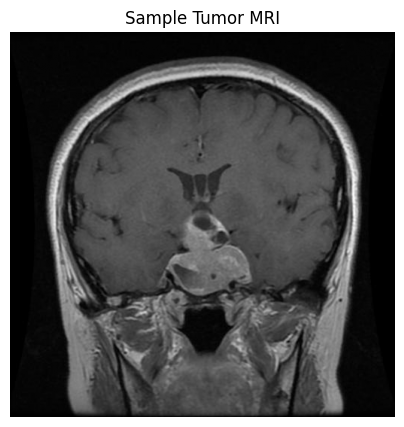

In [ ]:
sample_tumor = os.path.join(train_binary, "tumor", os.listdir(os.path.join(train_binary, "tumor"))[0])
img = cv2.imread(sample_tumor, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Sample Tumor MRI")
plt.axis("off")
plt.show()

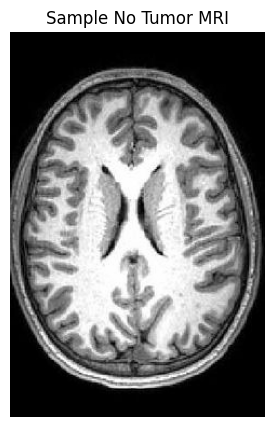

In [ ]:
sample_no = os.path.join(train_binary, "no_tumor", os.listdir(os.path.join(train_binary, "no_tumor"))[0])
img2 = cv2.imread(sample_no, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
plt.imshow(img2, cmap='gray')
plt.title("Sample No Tumor MRI")
plt.axis("off")
plt.show()

In [ ]:
def frequency_enhancement(img):
    img = cv2.resize(img, (256, 256))
    img_float = np.float32(img)

    dft = cv2.dft(img_float, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    mask = np.ones((rows, cols, 2), np.uint8)
    r = 20
    cv2.circle(mask, (ccol, crow), r, (0, 0), -1)

    filtered = dft_shift * mask
    f_ishift = np.fft.ifftshift(filtered)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(img_back)

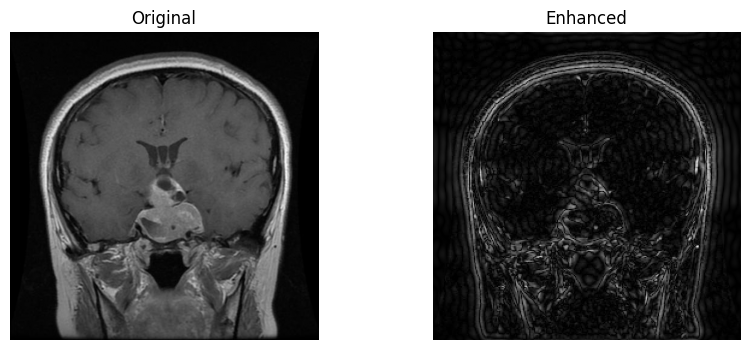

In [ ]:
enhanced = frequency_enhancement(img)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced")
plt.axis("off")
plt.show()

In [ ]:
def segment_tumor(img):
    blurred = cv2.GaussianBlur(img, (5,5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh

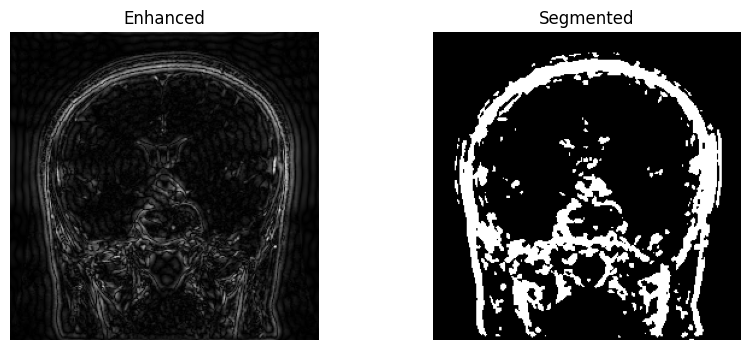

In [ ]:
seg = segment_tumor(enhanced)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(seg, cmap='gray')
plt.title("Segmented")
plt.axis("off")
plt.show()

In [ ]:
def clean_mask(mask):
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)
    dilated = cv2.dilate(closing, kernel, iterations=1)
    return dilated

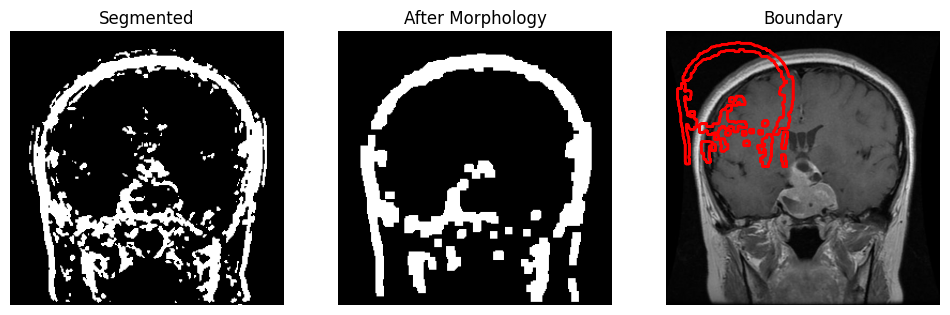

In [ ]:
cleaned = clean_mask(seg)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(seg, cmap='gray')
plt.title("Segmented")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cleaned, cmap='gray')
plt.title("After Morphology")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img, cmap='gray')
plt.contour(cleaned, colors='r')
plt.title("Boundary")
plt.axis("off")
plt.show()

In [ ]:
def extract_features(original_img, mask):
    labels = measure.label(mask, connectivity=2)
    props = measure.regionprops(labels, intensity_image=original_img)

    if len(props) == 0:
        return [0, 0, 0, 0, 0]

    largest = max(props, key=lambda x: x.area)

    area = largest.area
    perimeter = largest.perimeter if largest.perimeter > 0 else 1
    circularity = (4 * np.pi * area) / (perimeter ** 2)
    mean_intensity = largest.mean_intensity

    minr, minc, maxr, maxc = largest.bbox
    bbox_area = (maxr - minr) * (maxc - minc)
    extent = area / bbox_area if bbox_area > 0 else 0

    return [area, perimeter, circularity, mean_intensity, extent]

In [ ]:
features = extract_features(cv2.resize(img, (256,256)), cleaned)
print("Features:", features)

Features: [np.float64(4938.0), np.float64(831.6711395993651), np.float64(0.08971347675399079), np.float64(99.69177804779262), np.float64(0.1393655452698126)]


In [ ]:
def process_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))

    enhanced = frequency_enhancement(img)
    seg = segment_tumor(enhanced)
    cleaned = clean_mask(seg)
    feats = extract_features(img, cleaned)

    return img, enhanced, seg, cleaned, feats

Extracted features: [np.float64(4938.0), np.float64(831.6711395993651), np.float64(0.08971347675399079), np.float64(99.69177804779262), np.float64(0.1393655452698126)]


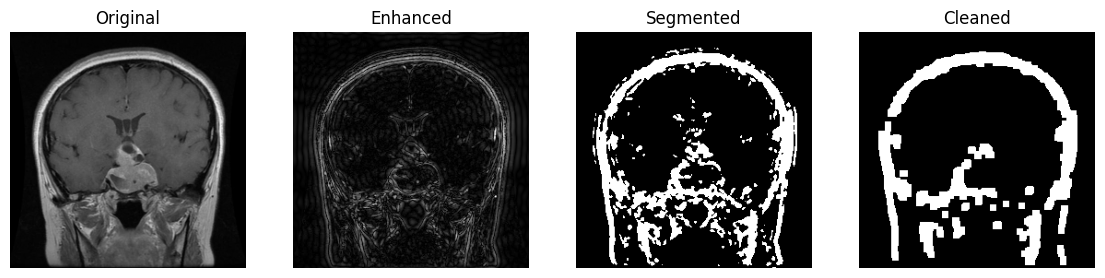

In [ ]:
img0, enh0, seg0, clean0, feat0 = process_image(sample_tumor)

print("Extracted features:", feat0)

plt.figure(figsize=(14,4))
titles = ["Original", "Enhanced", "Segmented", "Cleaned"]
images = [img0, enh0, seg0, clean0]

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")
plt.show()

In [ ]:
X_train, y_train = [], []
X_test, y_test = [], []

# training data
for label_name, label in [("tumor", 1), ("no_tumor", 0)]:
    folder = os.path.join(train_binary, label_name)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        try:
            _, _, _, _, feats = process_image(img_path)
            X_train.append(feats)
            y_train.append(label)
        except Exception as e:
            print("Skipping train:", img_path, e)

# testing data
for label_name, label in [("tumor", 1), ("no_tumor", 0)]:
    folder = os.path.join(test_binary, label_name)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        try:
            _, _, _, _, feats = process_image(img_path)
            X_test.append(feats)
            y_test.append(label)
        except Exception as e:
            print("Skipping test:", img_path, e)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5600, 5)
X_test shape: (1600, 5)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.816875

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.60      0.62       400
           1       0.87      0.89      0.88      1200

    accuracy                           0.82      1600
   macro avg       0.76      0.74      0.75      1600
weighted avg       0.81      0.82      0.81      1600


Confusion Matrix:

[[ 239  161]
 [ 132 1068]]


In [ ]:
def predict_image(path, model):
    img, enhanced, seg, cleaned, feats = process_image(path)
    pred = model.predict([feats])[0]
    label = "Tumor" if pred == 1 else "No Tumor"

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cleaned, cmap='gray')
    plt.title("Detected Region")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(img, cmap='gray')
    plt.contour(cleaned, colors='r')
    plt.title(f"Prediction: {label}")
    plt.axis("off")

    plt.show()
    return label

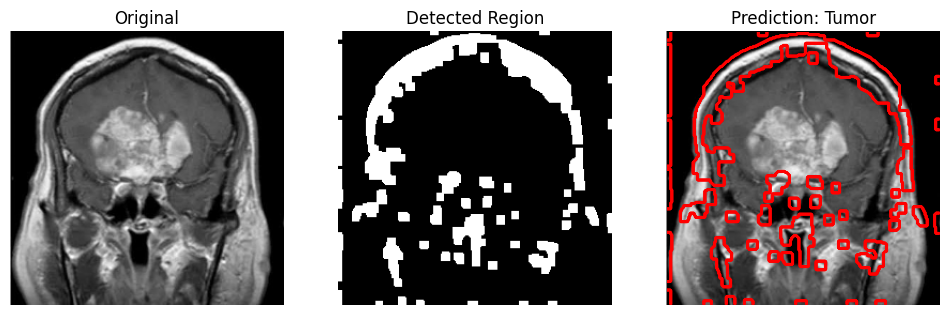

'Tumor'

In [ ]:
test_img = os.path.join(test_binary, "tumor", os.listdir(os.path.join(test_binary, "tumor"))[0])
predict_image(test_img, knn)

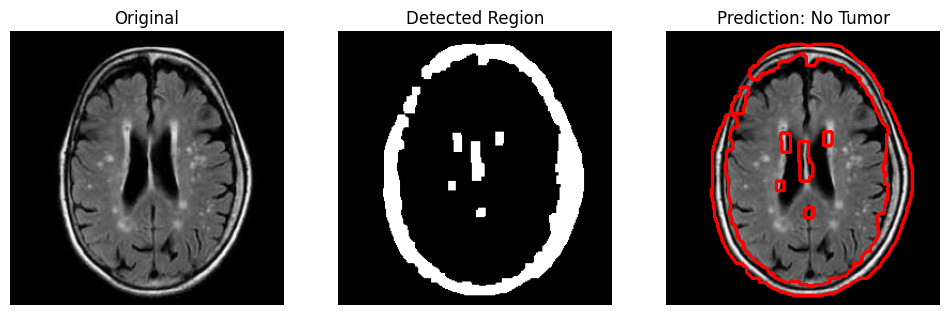

'No Tumor'

In [ ]:
test_img2 = os.path.join(test_binary, "no_tumor", os.listdir(os.path.join(test_binary, "no_tumor"))[0])
predict_image(test_img2, knn)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2026-04-23 at 00.05.27.jpeg to WhatsApp Image 2026-04-23 at 00.05.27.jpeg


In [ ]:
import os

uploaded_filename = list(uploaded.keys())[0]
print("Uploaded file:", uploaded_filename)

Uploaded file: WhatsApp Image 2026-04-23 at 00.05.27.jpeg


In [ ]:
def predict_uploaded_image(image_path, model):
    # process image using your pipeline
    img, enhanced, seg, cleaned, feats = process_image(image_path)

    # predict
    pred = model.predict([feats])[0]
    label = "Tumor" if pred == 1 else "No Tumor"

    # visualize steps (VERY IMPORTANT for presentation)
    plt.figure(figsize=(16,4))

    plt.subplot(1,4,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(enhanced, cmap='gray')
    plt.title("Enhanced (FFT)")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(cleaned, cmap='gray')
    plt.title("Detected Region")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(img, cmap='gray')
    plt.contour(cleaned, colors='r')
    plt.title(f"Prediction: {label}")
    plt.axis("off")

    plt.show()

    print("Extracted Features:", feats)
    print("Final Prediction:", label)

    return label

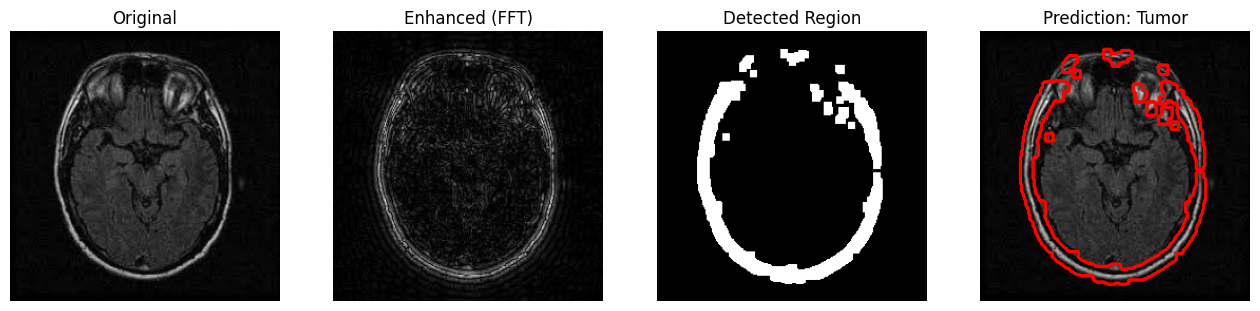

Extracted Features: [np.float64(5340.0), np.float64(864.0975464705581), np.float64(0.08987224222675395), np.float64(44.78239700374532), np.float64(0.15720678285445125)]
Final Prediction: Tumor


'Tumor'

In [ ]:
predict_uploaded_image(uploaded_filename, knn)

In [ ]:
def predict_with_confidence(image_path, model):
    img, enhanced, seg, cleaned, feats = process_image(image_path)

    probs = model.predict_proba([feats])[0]
    pred = model.predict([feats])[0]

    label = "Tumor" if pred == 1 else "No Tumor"
    confidence = max(probs)

    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}")

    return label

In [ ]:
predict_with_confidence(uploaded_filename, knn)

Prediction: Tumor
Confidence: 1.00


'Tumor'

In [ ]:
def tumor_severity(area):
    if area < 2000:
        return "Small Tumor"
    elif area < 6000:
        return "Medium Tumor"
    else:
        return "Large Tumor"


def tumor_percentage(mask):
    tumor_pixels = np.sum(mask > 0)
    total_pixels = mask.shape[0] * mask.shape[1]
    percentage = (tumor_pixels / total_pixels) * 100
    return percentage


def create_heatmap_overlay(original_img, mask):
    heatmap = cv2.applyColorMap(mask, cv2.COLORMAP_JET)
    original_bgr = cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR)

    overlay = cv2.addWeighted(original_bgr, 0.7, heatmap, 0.3, 0)

    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

In [ ]:
def predict_uploaded_image_advanced(image_path, model):
    img, enhanced, seg, cleaned, feats = process_image(image_path)

    pred = model.predict([feats])[0]
    probs = model.predict_proba([feats])[0]
    confidence = max(probs)

    label = "Tumor" if pred == 1 else "No Tumor"

    area = feats[0]
    severity = tumor_severity(area)
    percentage = tumor_percentage(cleaned)
    heatmap_overlay = create_heatmap_overlay(img, cleaned)

    plt.figure(figsize=(20,4))

    plt.subplot(1,5,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.imshow(enhanced, cmap='gray')
    plt.title("Enhanced FFT")
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.imshow(cleaned, cmap='gray')
    plt.title("Detected Region")
    plt.axis("off")

    plt.subplot(1,5,4)
    plt.imshow(img, cmap='gray')
    plt.contour(cleaned, colors='r')
    plt.title("Boundary")
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.imshow(heatmap_overlay)
    plt.title("Heatmap Overlay")
    plt.axis("off")

    plt.show()

    print("Final Prediction:", label)
    print(f"Confidence: {confidence:.2f}")

    if label == "Tumor":
        print("Tumor Severity:", severity)
        print(f"Tumor Area Percentage: {percentage:.2f}%")
    else:
        print("Tumor Severity: Not Applicable")
        print("Tumor Area Percentage: 0.00%")

    print("Extracted Features:", feats)

    return label

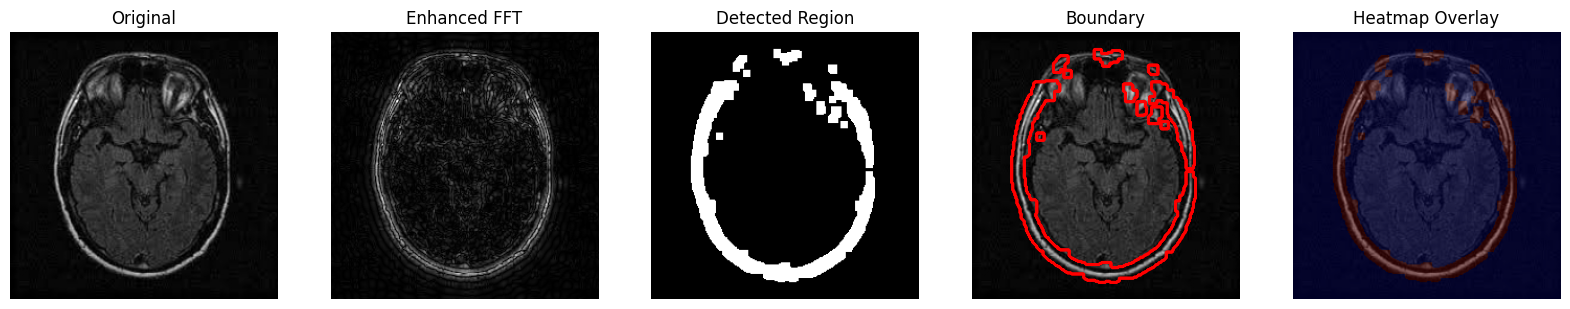

Final Prediction: Tumor
Confidence: 1.00
Tumor Severity: Medium Tumor
Tumor Area Percentage: 11.71%
Extracted Features: [np.float64(5340.0), np.float64(864.0975464705581), np.float64(0.08987224222675395), np.float64(44.78239700374532), np.float64(0.15720678285445125)]


'Tumor'

In [ ]:
predict_uploaded_image_advanced(uploaded_filename, knn)

In [ ]:
import joblib

joblib.dump(knn, "brain_tumor_knn.pkl")
print("Model saved successfully.")

Model saved successfully.


In [ ]:
from google.colab import files
files.download("brain_tumor_knn.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>